In [2]:
# 한글 깨짐 방지
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 57.5 MB/s eta 0:00:00


In [3]:
# 필요 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind # Welch t-test
from numpy import mean, std, sqrt
import warnings
warnings.filterwarnings('ignore')

In [4]:
# csv 파일 불러오고 데이터 확인
health_data = pd.read_csv("/content/smoking_health_data_preprocessed_v1.csv")
health_data.columns = [c.strip() for c in health_data.columns]    # 컬럼명 앞뒤 공백 제거

print(health_data.shape)    # (7000, 31)
print(health_data.info())
print("\n-----------------------------------------------------------------------------")
print(health_data.describe())

(7000, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   raw_id               7000 non-null   object 
 1   age                  7000 non-null   int64  
 2   height_cm            7000 non-null   int64  
 3   weight_kg            7000 non-null   int64  
 4   bmi                  7000 non-null   float64
 5   sight                7000 non-null   float64
 6   cavity               7000 non-null   int64  
 7   fasting_blood_sugar  7000 non-null   float64
 8   bp                   7000 non-null   float64
 9   triglyceride         7000 non-null   float64
 10  creatinine           7000 non-null   float64
 11  cholesterol          7000 non-null   int64  
 12  hdl                  7000 non-null   int64  
 13  ldl                  7000 non-null   int64  
 14  hemoglobin           7000 non-null   float64
 15  proteinuria          7000 n

In [7]:
# 시각화 파일 불러오기
import sys
sys.path.append("/content/smoke_viz.py")
from smoke_viz import *

In [8]:
# 가설
# 가설 1. '정상 BMI' 범위(예: 18.5 ≤ BMI < 25) 내의 흡연자와 비흡연자 그룹 간에 평균 '중성 지방 / 고밀도지단백(HDL) 비율'은 통계적으로 차이가 없다. (연구가설: 흡연자는 높은 (중성지방/HDL)값을 가질 것이다.)
# 가설 2. '동일 BMI' 범주에서 흡연 여부에 따른 '헤모글로빈 수치 / 간 효소율'의 분포 차이는 없다. (연구가설: 흡연자는 낮은 간 효소율, 높은 헤모글로빈 수치를 가질 것이다.)
# 가설 3. '정상 BMI' 범위에서 흡연 여부에 따른 나이, 크레아티닌의 분포 차이는 없다. (연구가설: 흡연자는 크레아티닌 수치가 더 높다.)

In [9]:
# 필요 파생 변수 생성
health_data['tgc_hdl_ratio'] = health_data['triglyceride'] / health_data['hdl']
health_data['hemo_lel_ratio'] = health_data['hemoglobin'] / health_data['liver_enzyme_level']

[저체중] n(흡연)=65, n(비흡연)=165 | mean(흡연)=1.504, sd(흡연)=0.880 | mean(비흡연)=1.160, sd(비흡연)=0.683 | p=0.005672 **
[정상] n(흡연)=1413, n(비흡연)=2901 | mean(흡연)=2.638, sd(흡연)=1.864 | mean(비흡연)=1.851, sd(비흡연)=1.367 | p=1.762e-43 ***
[과체중] n(흡연)=927, n(비흡연)=1166 | mean(흡연)=3.708, sd(흡연)=2.228 | mean(비흡연)=2.819, sd(비흡연)=1.882 | p=1.016e-21 ***
[비만] n(흡연)=166, n(비흡연)=197 | mean(흡연)=4.200, sd(흡연)=2.109 | mean(비흡연)=3.482, sd(비흡연)=2.270 | p=0.001976 **


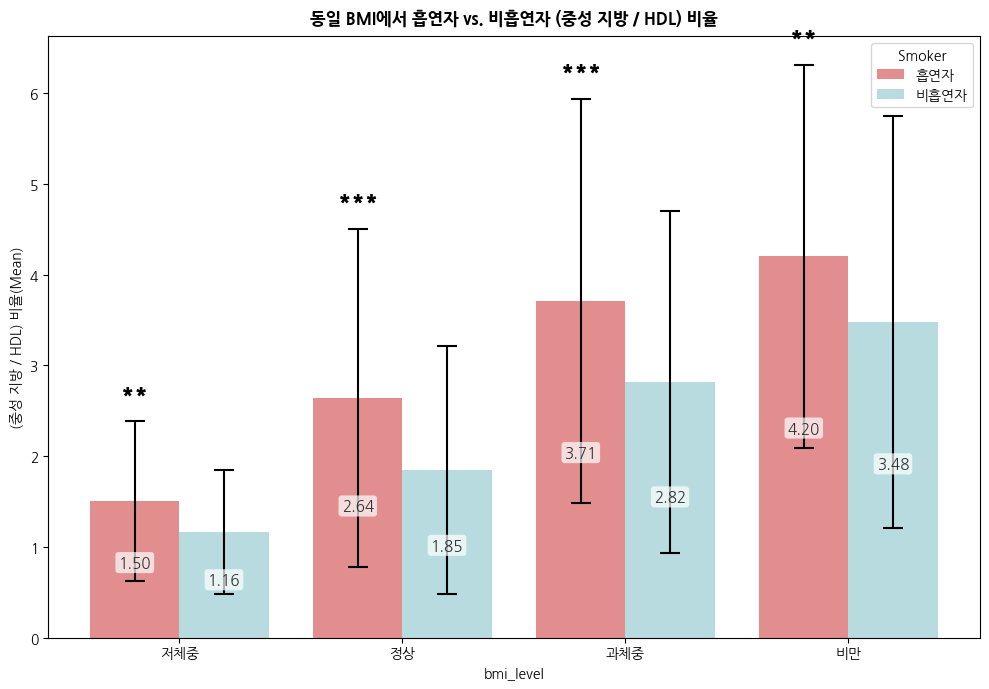

In [10]:
# 가설 1. '정상 BMI' 범위(예: 18.5 ≤ BMI < 25) 내의 흡연자와 비흡연자 그룹 간에 평균 '중성 지방 / 고밀도지단백(HDL) 비율'은 통계적으로 차이가 없다.
# (연구가설: 흡연자는 높은 (중성지방/HDL)값을 가질 것이다.)
# '정상 BMI 범위'로 좁힌 이유: 생활 습관에 의한 영향력을 최소화하고 흡연자와 비흡연자의 차이를 보기 위해서.

order = ['저체중', '정상', '과체중', '비만']

bar_with_hue(health_data, 'bmi_level', 'tgc_hdl_ratio',
             '동일 BMI에서 흡연자 vs. 비흡연자 (중성 지방 / HDL) 비율', '(중성 지방 / HDL) 비율(Mean)',
             hue='Smoker', order=order
             )

In [11]:
# Cohen’s d
# |d| ≈ 0.2 → 작은 효과
# |d| ≈ 0.5 → 중간 효과
# |d| ≥ 0.8 → 큰 효과

def cohens_d(x, y):
    """
    Cohen's d (pooled SD, Welch-friendly)
    x, y: array-like (흡연자, 비흡연자)
    """
    x = np.asarray(x)
    y = np.asarray(y)

    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)

    pooled_sd = np.sqrt((vx + vy) / 2)
    return (x.mean() - y.mean()) / pooled_sd

In [12]:
order = ['저체중', '정상', '과체중', '비만']

for bmi in order:
    smoker_vals = health_data[
        (health_data["bmi_level"] == bmi) &
        (health_data["Smoker"] == "흡연자")
    ]["tgc_hdl_ratio"]

    nonsmoker_vals = health_data[
        (health_data["bmi_level"] == bmi) &
        (health_data["Smoker"] == "비흡연자")
    ]["tgc_hdl_ratio"]

    if len(smoker_vals) < 2 or len(nonsmoker_vals) < 2:
        continue

    d = cohens_d(smoker_vals, nonsmoker_vals)

    print(f"[{bmi}] Cohen’s d = {d:.3f}")

[저체중] Cohen’s d = 0.436
[정상] Cohen’s d = 0.482
[과체중] Cohen’s d = 0.431
[비만] Cohen’s d = 0.327


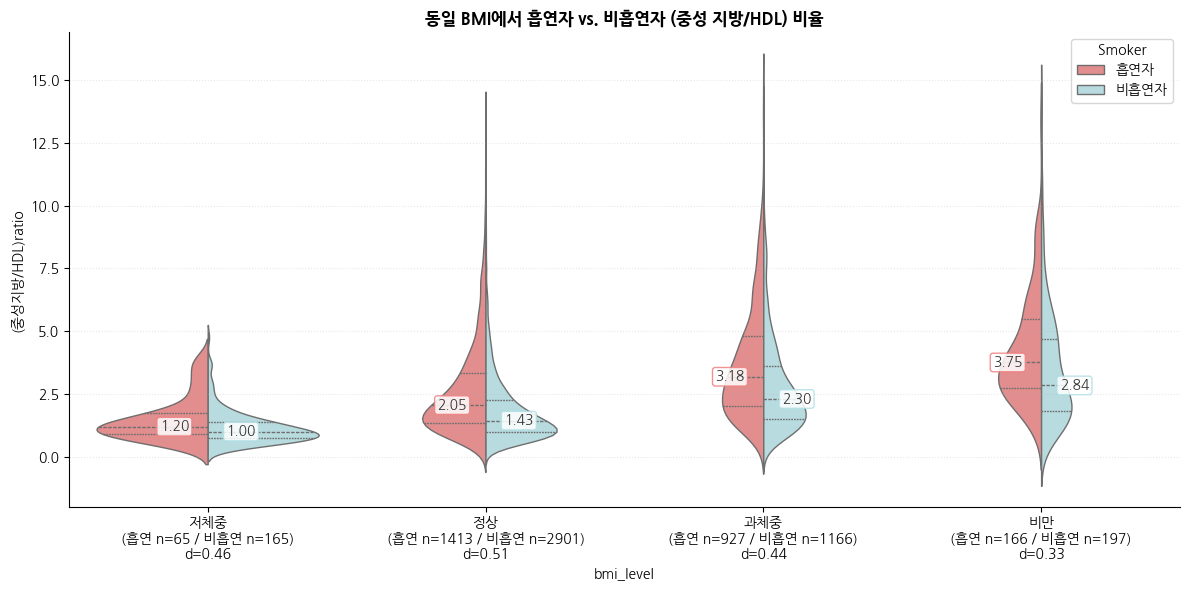

In [13]:
order = ["저체중", "정상", "과체중", "비만"]
violin_with_median(health_data, "bmi_level", "tgc_hdl_ratio", "동일 BMI에서 흡연자 vs. 비흡연자 (중성 지방/HDL) 비율", "(중성지방/HDL)ratio", hue="Smoker", order=order)

In [14]:
# Mann–Whitney U test

from scipy.stats import mannwhitneyu

results = []

for bmi in ["저체중", "정상", "과체중", "비만"]:

    subset = health_data[
        health_data["bmi_level"] == bmi
    ]

    smoker = subset.loc[
        subset["Smoker"] == "흡연자",
        "tgc_hdl_ratio"
    ]

    nonsmoker = subset.loc[
        subset["Smoker"] == "비흡연자",
        "tgc_hdl_ratio"
    ]

    # 표본이 충분할 때만 검정
    if len(smoker) > 10 and len(nonsmoker) > 10:
        stat, p = mannwhitneyu(
            smoker,
            nonsmoker,
            alternative="two-sided"
        )

        results.append({
            "BMI 그룹": bmi,
            "흡연자 수": len(smoker),
            "비흡연자 수": len(nonsmoker),
            "p-value": p
        })

results_df = pd.DataFrame(results)
results_df

,BMI 그룹,흡연자 수,비흡연자 수,p-value
0,저체중,65,165,2.115818e-03
1,정상,1413,2901,3.020197e-59
2,과체중,927,1166,1.564485e-25
3,비만,166,197,4.931360e-05


# 가설 1. 정상 BMI에서 흡연자는 TG/HDL 비율이 더 높다

## 📊 Results
### 1. 연구 대상자의 BMI 그룹별 특성

- 전체 연구 대상자는 BMI 수준에 따라 저체중, 정상, 과체중, 비만의 네 그룹으로 분류되었다.

- 각 BMI 그룹 내에서 흡연자와 비흡연자의 중성지방/고밀도지단백(Triglyceride/HDL) 비율의 평균과 표준편차를 비교하였다.

### 2. BMI 그룹별 흡연 여부에 따른 (중성지방/HDL) 비율 비교

- 모든 BMI 그룹에서 흡연자는 비흡연자에 비해 평균 중성지방/HDL 비율이 더 높게 나타났다.

- 저체중 그룹에서 흡연자의 평균 비율은 1.50(SD=0.88), 비흡연자는 1.16(SD=0.68)이었으며, 두 집단 간 차이는 통계적으로 유의하였다 (Welch’s t-test, p = 0.0057).

- 정상 BMI 그룹에서 흡연자의 평균 비율은 2.64(SD=1.86), 비흡연자는 1.85(SD=1.37)이었고, 두 집단 간 차이는 매우 유의하였다 (p < 0.001).

- 과체중 그룹에서도 흡연자의 평균 비율은 3.71 (SD=2.23)로 비흡연자의 평균 비율인 2.82 (SD=1.88)에 비해 유의하게 높은 값을 보였다 (p < 0.001).

- 비만 그룹에서도 흡연자의 평균 비율은 4.20(SD=2.11), 비흡연자는 3.48(SD=2.27)로 나타났으며, 두 집단 간 차이는 통계적으로 유의하였다 (p = 0.002).

### 3. 시각화를 통한 분포 및 변동성 확인

- 막대그래프와 표준편차 기반 오차막대를 통해, BMI 수준이 증가할수록 중성지방/HDL 비율의 평균값과 변동성이 함께 증가하는 경향이 관찰되었다.
- 특히 흡연자 그룹에서는 BMI 증가에 따라 평균값 상승 폭이 비흡연자보다 더 크게 나타났다.
- 각 BMI 그룹에서 흡연자와 비흡연자 간 평균 차이는 시각적으로도 일관되게 확인되었다.

### 4. 가설 검정 결과 요약

- 정상 BMI 범위(18.5 ≤ BMI < 25) 내에서 흡연자와 비흡연자의 중성지방/HDL 비율은 동일하다는 귀무가설은 기각되었다.
- 흡연자는 정상 BMI 범위에서도 비흡연자에 비해 유의하게 높은 중성지방/HDL 비율을 보였다.

## 📌 Results 핵심 요약

- 모든 BMI 그룹에서 흡연자는 비흡연자보다 높은 (중성지방/HDL) 비율을 보였다.
- 정상 BMI 범위에서도 흡연 여부에 따른 차이는 통계적으로 매우 유의하였다.
- BMI 증가에 따라 (중성지방/HDL) 비율의 평균과 변동성이 함께 증가하는 경향이 관찰되었으며, 이 경향은 흡연자 그룹에서 더 뚜렷했다.
- 흡연자 평균은 비흡연자 평균보다 집단 내 변동성을 기준으로 약 0.4 표준편차만큼 높다(cohen's d)

[저체중] n(흡연)=65, n(비흡연)=165 | mean(흡연)=11.038, sd(흡연)=3.772 | mean(비흡연)=9.733, sd(비흡연)=3.218 | p=0.01564 *
[정상] n(흡연)=1413, n(비흡연)=2901 | mean(흡연)=15.126, sd(흡연)=6.260 | mean(비흡연)=12.373, sd(비흡연)=5.039 | p=3.56e-45 ***
[과체중] n(흡연)=927, n(비흡연)=1166 | mean(흡연)=19.469, sd(흡연)=6.975 | mean(비흡연)=15.892, sd(비흡연)=6.638 | p=1.35e-31 ***
[비만] n(흡연)=166, n(비흡연)=197 | mean(흡연)=23.665, sd(흡연)=7.212 | mean(비흡연)=19.496, sd(비흡연)=7.828 | p=2.283e-07 ***


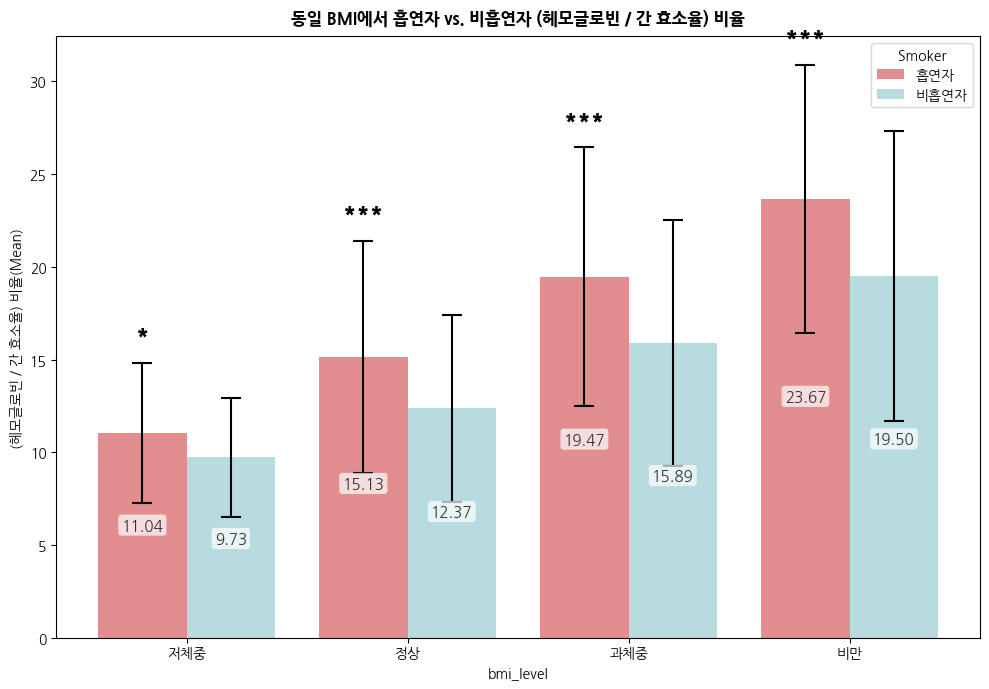

In [54]:
# 가설 2. '동일 BMI' 범주에서 흡연 여부에 따른 '헤모글로빈 수치 / 간 효소율'의 분포 차이는 없다.
# (연구가설: 흡연자는 낮은 간 효소율, 높은 헤모글로빈 수치를 가질 것이다.)
order = ['저체중', '정상', '과체중', '비만']

bar_with_hue(health_data, 'bmi_level', 'hemo_lel_ratio',
             '동일 BMI에서 흡연자 vs. 비흡연자 (헤모글로빈 / 간 효소율) 비율', '(헤모글로빈 / 간 효소율) 비율(Mean)',
             hue='Smoker', order=order
             )

In [50]:
order = ['저체중', '정상', '과체중', '비만']

for bmi in order:
    smoker_vals = health_data[
        (health_data["bmi_level"] == bmi) &
        (health_data["Smoker"] == "흡연자")
    ]["hemo_lel_ratio"]

    nonsmoker_vals = health_data[
        (health_data["bmi_level"] == bmi) &
        (health_data["Smoker"] == "비흡연자")
    ]["hemo_lel_ratio"]

    if len(smoker_vals) < 2 or len(nonsmoker_vals) < 2:
        continue

    d = cohens_d(smoker_vals, nonsmoker_vals)

    print(f"[{bmi}] Cohen’s d = {d:.3f}")

[저체중] Cohen’s d = 0.372
[정상] Cohen’s d = 0.484
[과체중] Cohen’s d = 0.525
[비만] Cohen’s d = 0.554


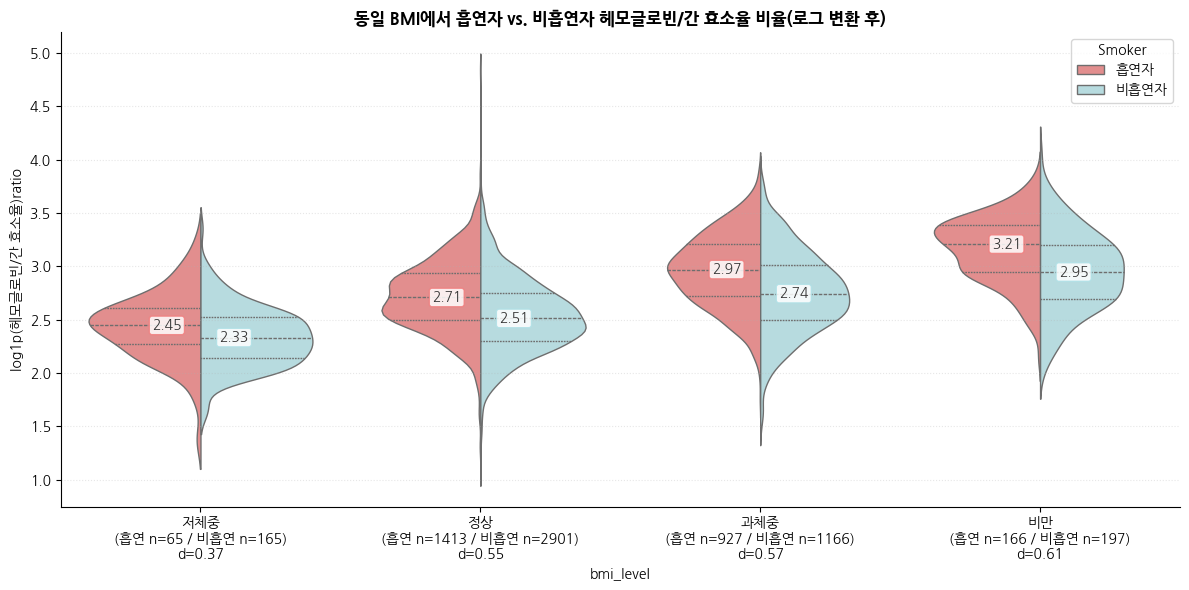

In [66]:
order = ["저체중", "정상", "과체중", "비만"]
health_data["hb_le_ratio_log"] = np.log1p(health_data['hemo_lel_ratio'])
violin_with_median(health_data, "bmi_level", "hb_le_ratio_log", "동일 BMI에서 흡연자 vs. 비흡연자 헤모글로빈/간 효소율 비율(로그 변환 후)", "log1p(헤모글로빈/간 효소율)ratio", hue="Smoker", order=order)

In [61]:
# Mann–Whitney U test

from scipy.stats import mannwhitneyu

results = []

for bmi in ["저체중", "정상", "과체중", "비만"]:

    subset = health_data[
        health_data["bmi_level"] == bmi
    ]

    smoker = subset.loc[
        subset["Smoker"] == "흡연자",
        "hb_le_ratio_log"
    ]

    nonsmoker = subset.loc[
        subset["Smoker"] == "비흡연자",
        "hb_le_ratio_log"
    ]

    # 표본이 충분할 때만 검정
    if len(smoker) > 10 and len(nonsmoker) > 10:
        stat, p = mannwhitneyu(
            smoker,
            nonsmoker,
            alternative="two-sided"
        )

        results.append({
            "BMI 그룹": bmi,
            "흡연자 수": len(smoker),
            "비흡연자 수": len(nonsmoker),
            "p-value": p
        })

results_df = pd.DataFrame(results)
results_df

,BMI 그룹,흡연자 수,비흡연자 수,p-value
0,저체중,65,165,5.423059e-03
1,정상,1413,2901,1.059015e-66
2,과체중,927,1166,7.918479e-36
3,비만,166,197,1.408394e-08


# 가설 2. BMI 범주별로(저체중/정상/과체중/비만) 흡연자는 Hb/Liver enzyme 비율 분포가 비흡연자와 다를 것이다

## 📊 Results
1. BMI 그룹별 흡연 여부에 따른 (헤모글로빈 / 간 효소) 비율 비교

- BMI 수준별로 흡연자와 비흡연자의 헤모글로빈/간 효소 비율을 비교한 결과,
모든 BMI 그룹에서 흡연자가 비흡연자보다 유의하게 높은 값을 보였다.

- 저체중 그룹에서 흡연자의 평균 비율은 11.04 (SD = 3.77), 비흡연자는 9.73 (SD = 3.22)였으며,
두 집단 간 차이는 통계적으로 유의하였다 (Welch’s t-test, p = 0.0156).

- 정상 BMI 그룹에서 흡연자의 평균은 15.13 (SD = 6.26), 비흡연자는 12.37 (SD = 5.04)로 나타났고,
두 집단 간 차이는 매우 유의하였다 (p < 0.001).

- 과체중 그룹에서도 흡연자(19.47 ± 6.98)는 비흡연자(15.89 ± 6.64)에 비해
유의하게 높은 비율을 보였다 (p < 0.001).

- 비만 그룹에서도 흡연자의 평균 비율은 23.67 (SD = 7.21), 비흡연자는 19.50 (SD = 7.83)로 나타났으며,
두 집단 간 차이는 통계적으로 유의하였다 (p < 0.001).

## 2. 비모수 검정을 통한 분포 차이 검증 (Mann-Whitney U test)

- 해당 비율은 비정규 분포 및 극단값(outlier)의 가능성을 고려하여,
각 BMI 그룹별로 Mann-Whitney U test를 추가 수행하였다.

- 그 결과, 모든 BMI 그룹에서 흡연자와 비흡연자 간 분포 차이는 일관되게 유의하였다
(p < 0.01, 모든 그룹).

- 이는 평균 차이뿐 아니라 분포 전반의 위치 차이(location shift)가 존재함을 시사한다.

## 3. 효과 크기 분석 (Cohen’s d)

흡연 여부에 따른 효과 크기를 Cohen’s d로 평가한 결과는 다음과 같다.

| BMI 그룹 | Cohen’s d | 해석 |
|---------|-----------|-----|
| 저체중 | 0.37 | 작은~중간 효과 |
| 정상 | 0.48 | 중간 효과 |
| 과체중 | 0.53 | 중간 효과 |
| 비만 | 0.55 | 중간 효과 |

특히 BMI가 증가할수록 효과 크기가 커지는 경향이 관찰되었으며,
이는 흡연의 대사적 영향이 체중 증가와 함께 증폭될 가능성을 시사한다.

## 4. 시각화 기반 분포 해석 (로그 변환 바이올린 플롯)

- 로그 변환된 헤모글로빈/간 효소 비율의 바이올린 플롯 분석 결과,
모든 BMI 그룹에서 흡연자의 중앙값(median)이 비흡연자보다 높게 위치하였다.

- 흡연자 그룹은 분포의 상단 꼬리가 더 길어,
고비율 값의 빈도가 상대적으로 높음을 시각적으로 확인할 수 있었다.

- 이러한 경향은 과체중 및 비만 그룹에서 특히 두드러졌다.

## 5. 가설 검정 결과 요약

동일 BMI 범주 내에서 흡연 여부에 따라 헤모글로빈/간 효소 비율의 분포 차이가 없다는 귀무가설은 모든 BMI 그룹에서 기각되었다.
흡연자는 BMI 수준과 무관하게 비흡연자에 비해 유의하게 높은 헤모글로빈/간 효소 비율을 보였다.

## 📌 Results 핵심 요약 (논문용 Bullet)

- 모든 BMI 그룹에서 흡연자는 비흡연자보다 높은 (헤모글로빈/간 효소) 비율을 보였다.
- Welch’s t-test와 Mann-Whitney U test 모두에서 일관된 유의성이 확인되었다.
- 효과 크기(Cohen’s d)는 정상~비만 그룹에서 중간 효과 수준을 보였다.
- BMI 증가에 따라 흡연의 대사적 영향이 강화되는 경향이 관찰되었다.


[저체중] n(흡연)=65, n(비흡연)=165 | mean(흡연)=0.625, sd(흡연)=0.089 | mean(비흡연)=0.562, sd(비흡연)=0.081 | p=2.598e-06 ***
[정상] n(흡연)=1413, n(비흡연)=2901 | mean(흡연)=0.658, sd(흡연)=0.089 | mean(비흡연)=0.598, sd(비흡연)=0.111 | p=6.946e-78 ***
[과체중] n(흡연)=927, n(비흡연)=1166 | mean(흡연)=0.672, sd(흡연)=0.087 | mean(비흡연)=0.636, sd(비흡연)=0.109 | p=1.412e-16 ***
[비만] n(흡연)=166, n(비흡연)=197 | mean(흡연)=0.663, sd(흡연)=0.082 | mean(비흡연)=0.621, sd(비흡연)=0.105 | p=3.213e-05 ***


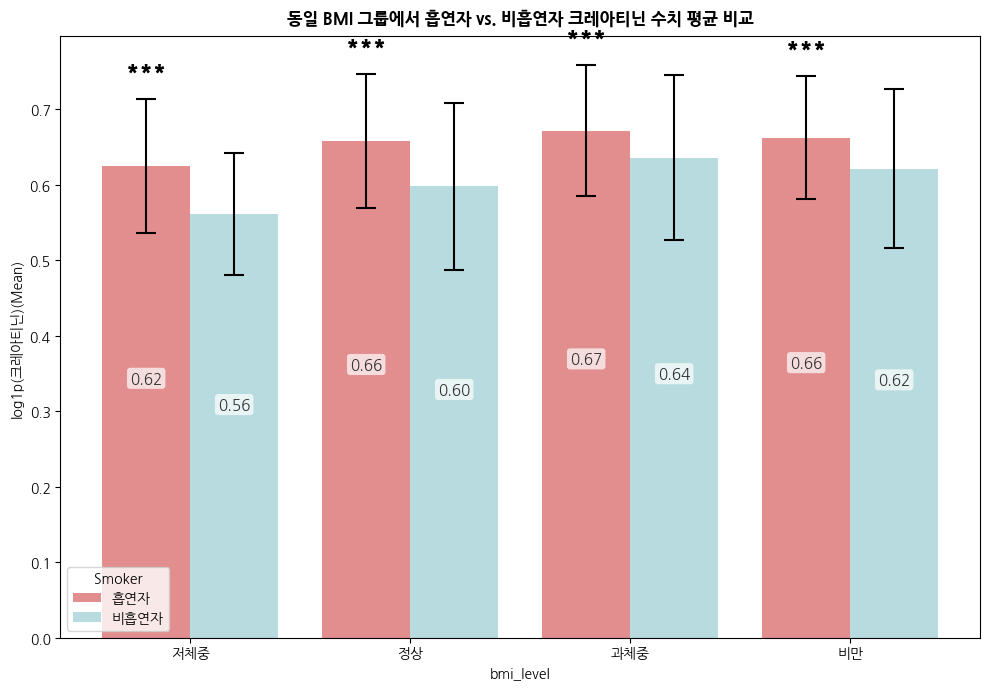

In [64]:
# 가설 3. '정상 BMI' 범위에서 흡연 여부에 따른 나이, 크레아티닌의 분포 차이는 없다.
# (연구가설: 흡연자는 크레아티닌 수치가 더 높다.)

order = ['저체중', '정상', '과체중', '비만']

bar_with_hue(health_data, 'bmi_level', 'creatinine_log',
             '동일 BMI 그룹에서 흡연자 vs. 비흡연자 크레아티닌 수치 평균 비교', 'log1p(크레아티닌)(Mean)',
             hue='Smoker', order=order
             )

In [52]:
order = ['저체중', '정상', '과체중', '비만']

for bmi in order:
    smoker_vals = health_data[
        (health_data["bmi_level"] == bmi) &
        (health_data["Smoker"] == "흡연자")
    ]["creatinine_log"]

    nonsmoker_vals = health_data[
        (health_data["bmi_level"] == bmi) &
        (health_data["Smoker"] == "비흡연자")
    ]["creatinine_log"]

    if len(smoker_vals) < 2 or len(nonsmoker_vals) < 2:
        continue

    d = cohens_d(smoker_vals, nonsmoker_vals)

    print(f"[{bmi}] Cohen’s d = {d:.3f}")

[저체중] Cohen’s d = 0.741
[정상] Cohen’s d = 0.599
[과체중] Cohen’s d = 0.362
[비만] Cohen’s d = 0.439


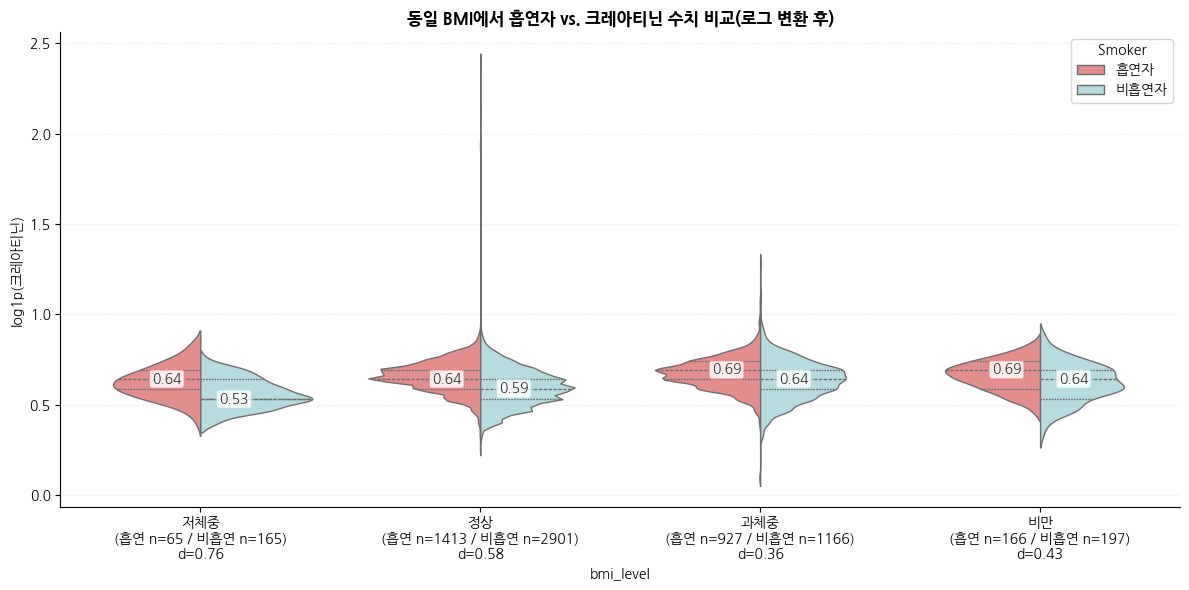

In [65]:
order = ["저체중", "정상", "과체중", "비만"]
violin_with_median(health_data, "bmi_level", "creatinine_log", "동일 BMI에서 흡연자 vs. 크레아티닌 수치 비교(로그 변환 후)", "log1p(크레아티닌)", hue="Smoker", order=order)

In [68]:
# Mann–Whitney U test

from scipy.stats import mannwhitneyu

results = []

for bmi in ["저체중", "정상", "과체중", "비만"]:

    subset = health_data[
        health_data["bmi_level"] == bmi
    ]

    smoker = subset.loc[
        subset["Smoker"] == "흡연자",
        "creatinine_log"
    ]

    nonsmoker = subset.loc[
        subset["Smoker"] == "비흡연자",
        "creatinine_log"
    ]

    # 표본이 충분할 때만 검정
    if len(smoker) > 10 and len(nonsmoker) > 10:
        stat, p = mannwhitneyu(
            smoker,
            nonsmoker,
            alternative="two-sided"
        )

        results.append({
            "BMI 그룹": bmi,
            "흡연자 수": len(smoker),
            "비흡연자 수": len(nonsmoker),
            "p-value": p
        })

results_df = pd.DataFrame(results)
results_df

,BMI 그룹,흡연자 수,비흡연자 수,p-value
0,저체중,65,165,2.849631e-06
1,정상,1413,2901,1.765761e-85
2,과체중,927,1166,9.108899e-17
3,비만,166,197,9.204266e-05


# 가설 3. 정상 BMI에서 흡연자는 크레아티닌(로그변환) 수치가 더 높다

# 📊 Results
## 1. 연구 가설 3 개요

- 귀무가설:
동일 BMI 범주 내에서 흡연 여부에 따른 크레아티닌 수치(log 변환)의 분포 차이는 없다.

- 연구가설:
흡연자는 비흡연자에 비해 더 높은 크레아티닌 수치를 보일 것이다.

## 2. BMI 그룹별 흡연 여부에 따른 크레아티닌 수치 비교

- BMI 수준별로 흡연자와 비흡연자의 log 변환된 크레아티닌 수치를 비교한 결과,
모든 BMI 그룹에서 흡연자가 비흡연자보다 유의하게 높은 평균값을 보였다.

- 저체중 그룹에서 흡연자의 평균 크레아티닌 수치는 0.625 (SD = 0.089), 비흡연자는 0.562 (SD = 0.081)였으며,
두 집단 간 차이는 통계적으로 유의하였다 (Welch’s t-test, p < 0.001).

- 정상 BMI 그룹에서도 흡연자의 평균은 0.658 (SD = 0.089), 비흡연자는 0.598 (SD = 0.111)로 나타났고,
두 집단 간 차이는 매우 유의하였다 (p < 0.001).

- 과체중 그룹에서 흡연자는 0.672 ± 0.087, 비흡연자는 0.636 ± 0.109로,
흡연자에서 유의하게 높은 값을 보였다 (p < 0.001).

- 비만 그룹에서도 흡연자의 평균 크레아티닌 수치는 0.663 (SD = 0.082), 비흡연자는 **0.621 (SD = 0.105)**로 나타났으며,
두 집단 간 차이는 통계적으로 유의하였다 (p < 0.001).

## 3. 비모수 검정을 통한 분포 차이 검증 (Mann-Whitney U test)

- 크레아티닌 수치는 분포의 비대칭성과 극단값(outlier)의 영향을 고려하여,
각 BMI 그룹별로 Mann–Whitney U test를 추가 수행하였다.

- 그 결과, 모든 BMI 그룹에서 흡연자와 비흡연자 간 크레아티닌 분포 차이는 일관되게 유의하였다(p < 0.001, 모든 그룹).

- 이는 평균 차이뿐 아니라 **분포 전체의 위치 이동(location shift)**이 존재함을 시사한다.

## 4. 효과 크기 분석 (Cohen’s d)

흡연 여부에 따른 효과 크기를 Cohen’s d로 평가한 결과는 다음과 같다.

| BMI 그룹 | Cohen’s d | 해석 |
|---------|-----------|-----|
| 저체중 | 0.74 | 중~큰 효과 |
| 정상 | 0.60 | 중간 효과 |
| 과체중 | 0.36 | 작은~중간 효과 |
| 비만 | 0.44 | 중간 효과 |

저체중 및 정상 BMI 그룹에서 상대적으로 큰 효과 크기가 관찰되었으며,
BMI가 증가함에 따라 효과 크기는 다소 감소하는 경향을 보였다.

## 5. 시각화 기반 분포 해석 (로그 변환 바이올린 플롯)

- 로그 변환된 크레아티닌 수치의 바이올린 플롯 분석 결과, 모든 BMI 그룹에서 흡연자의 중앙값(median)이 비흡연자보다 높게 위치하였다.

- 흡연자 그룹은 분포 상단 꼬리가 상대적으로 길어,
높은 크레아티닌 값의 빈도가 더 높음을 시각적으로 확인할 수 있었다.

- 이러한 경향은 특히 저체중 및 정상 BMI 그룹에서 두드러지게 나타났다.

## 6. 가설 검정 결과 요약

- 동일 BMI 범주 내에서 흡연 여부에 따라 크레아티닌 수치의 분포 차이가 없다는
귀무가설은 모든 BMI 그룹에서 기각되었다.

- 흡연자는 BMI 수준과 무관하게 비흡연자에 비해 유의하게 높은 크레아티닌 수치를 보였으며,
이는 흡연이 신장 관련 대사 지표에 독립적인 영향을 미칠 가능성을 시사한다.

# 📌 Results 핵심 요약 (논문용 Bullet)

- 모든 BMI 그룹에서 흡연자는 비흡연자보다 높은 크레아티닌 수치를 보였다.

- Welch’s t-test와 Mann-Whitney U test 모두에서 일관된 통계적 유의성이 확인되었다.

- 효과 크기(Cohen’s d)는 저체중·정상 BMI에서 중간 이상 수준을 보였다.

- 흡연의 신장 대사 관련 영향은 BMI가 낮을수록 더 명확하게 관찰되었다.